# Model Evaluation

## Imports

In [12]:
from ultralytics import YOLO
import random
import os
import matplotlib.pyplot as plt

## Set Seed

In [10]:
random_seed = 42

random.seed(random_seed)

## Load Model

In [2]:
model = YOLO("../runs/runs/traffic_sign_v1/weights/best.pt")

## Test Set Run

In [3]:
metrics = model.val(
    data="../data/processed/data.yaml",
    split="test",

    save=False,        # no images
    save_txt=False,    # no txt predictions
    save_json=False,   # no json outputs
    plots=False,       # no plots

    exist_ok=True
)

Ultralytics 8.4.45  Python-3.8.5 torch-2.4.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3070, 8191MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 62.710.6 MB/s, size: 316.3 KB)
val: Scanning F:\Software\Dataspell\TrafficSignDetection\data\processed\labels\test.cache... 91 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 91/91  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.6it/s 3.6s0.1s3s
                   all         91        164      0.958      0.965      0.964      0.799
Speed: 0.7ms preprocess, 3.6ms inference, 0.0ms loss, 0.8ms postprocess per image


## Results

In [8]:
print("\n=== Evaluation Results ===")

print(f"Precision   : {metrics.box.mp:.4f}")
print(f"Recall      : {metrics.box.mr:.4f}")
print(f"mAP@0.50    : {metrics.box.map50:.4f}")
print(f"mAP@0.50-95 : {metrics.box.map:.4f}")


=== Evaluation Results ===
Precision   : 0.9576
Recall      : 0.9646
mAP@0.50    : 0.9643
mAP@0.50-95 : 0.7993


## Sample Predictions

In [11]:
test_dir = "../data/processed/images/test"

images = os.listdir(test_dir)
sample = random.sample(images, 10)

sample_paths = [os.path.join(test_dir, img) for img in sample]

In [20]:
results = model.predict(
    sample_paths,
    save=False,
)


0: 384x640 2 traffic_signs, 21.7ms
1: 384x640 1 traffic_sign, 21.7ms
2: 384x640 2 traffic_signs, 21.7ms
3: 384x640 1 traffic_sign, 21.7ms
4: 384x640 3 traffic_signs, 21.7ms
5: 384x640 3 traffic_signs, 21.7ms
6: 384x640 2 traffic_signs, 21.7ms
7: 384x640 2 traffic_signs, 21.7ms
8: 384x640 2 traffic_signs, 21.7ms
9: 384x640 1 traffic_sign, 21.7ms
Speed: 2.6ms preprocess, 21.7ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)


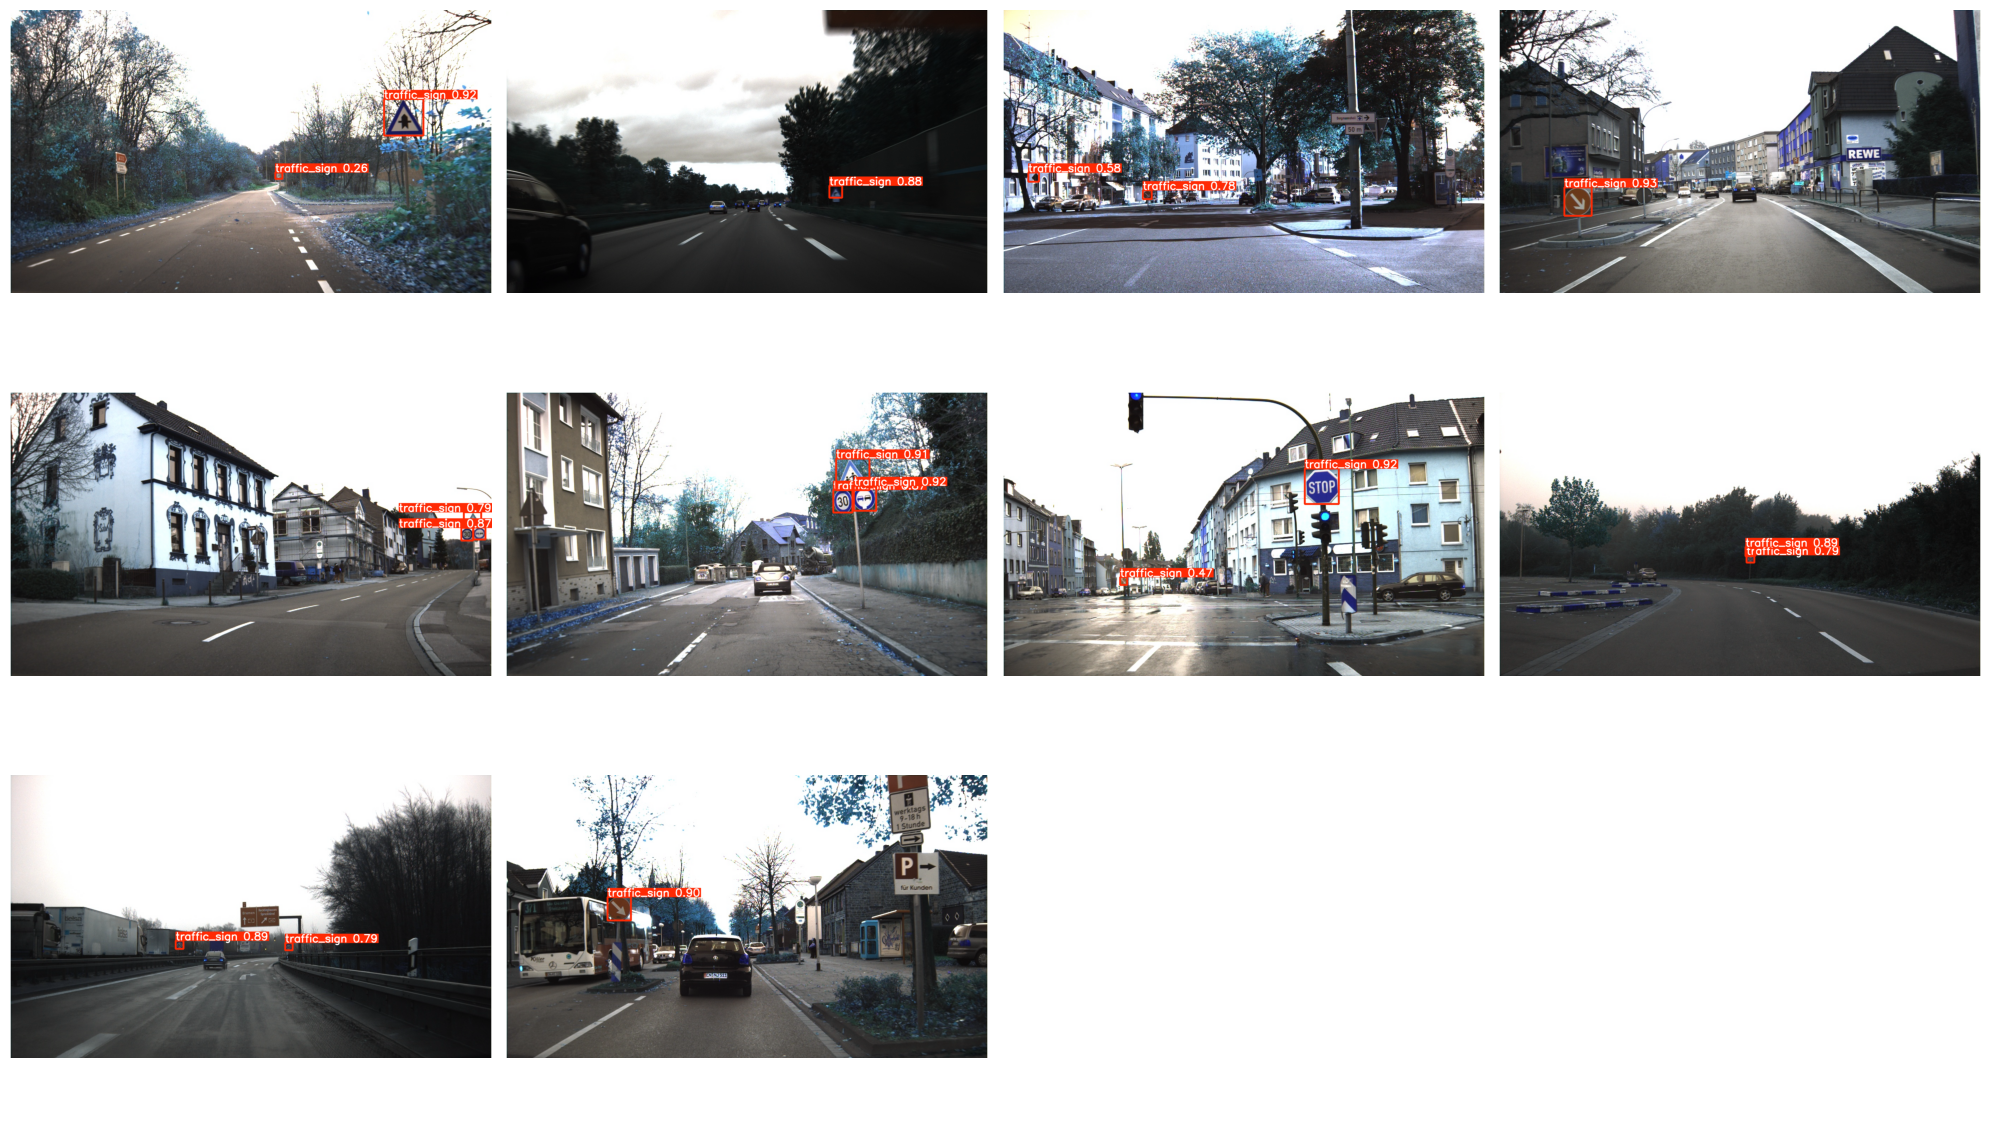

In [26]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.ravel()

for i, r in enumerate(results[:10]):
    img = r.plot()

    axes[i].imshow(img)
    axes[i].axis("off")

for ax in axes[len(results):]:
    ax.axis("off")

plt.tight_layout()
plt.show()